# ModalIn — AI Credit Scoring Model
**Capstone Project**

Notebook ini membangun model Deep Learning untuk memprediksi **skor kredit UMKM** menggunakan:
- ✅ TensorFlow Functional API
- ✅ Custom Layer (`CreditScoringLayer`)
- ✅ Custom Training Loop (`tf.GradientTape`)
- ✅ Model disimpan dalam format `.keras`
- ✅ SHAP untuk Explainable AI

In [4]:
!pip install tensorflow scikit-learn pandas numpy shap matplotlib -q


## 1. Import Library & Load Dataset

In [ ]:
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version : {tf.__version__}")

#Load Dataset
df = pd.read_csv("dataset_modalin_clean.csv")
print(f"Shape dataset      : {df.shape}")
print(f"Kolom              : {df.columns.tolist()}")
print(f"\nMissing values:")
print(df.isnull().sum())
df.head()


TensorFlow version : 2.20.0
Shape dataset      : (998, 18)
Kolom              : ['nik_id', 'jenis_usaha', 'lama_bln', 'omzet', 'pengeluaran', 'aset', 'hutang', 'freq_trx', 'total_skor', 'limit_pinjaman', 'laba_bersih', 'margin_laba', 'status_approval', 'risk_tier', 'dar_ratio', 'avg_trx_value', 'kategori_umur', 'oer_ratio']

Missing values:
nik_id             0
jenis_usaha        0
lama_bln           0
omzet              0
pengeluaran        0
aset               0
hutang             0
freq_trx           0
total_skor         0
limit_pinjaman     0
laba_bersih        0
margin_laba        0
status_approval    0
risk_tier          0
dar_ratio          0
avg_trx_value      0
kategori_umur      0
oer_ratio          0
dtype: int64


,nik_id,jenis_usaha,lama_bln,omzet,pengeluaran,aset,hutang,freq_trx,total_skor,limit_pinjaman,laba_bersih,margin_laba,status_approval,risk_tier,dar_ratio,avg_trx_value,kategori_umur,oer_ratio
0,3578223005401501,Bisnis Kuliner,97.0,39913810.0,26799102,42456926,25014643,289,625,13400000.0,13114708.0,32.857570,Disetujui,Bronze (Fair),0.589177,1.381101e+05,Matang (>5 Tahun),0.671424
1,3578748913461122,Jasa & Freelancer,7.0,6999315.0,3958719,67454433,27270764,23,507,5500000.0,3040596.0,43.441337,Disetujui,Bronze (Fair),0.404284,3.043180e+05,Baru (0-1 Tahun),0.565587
2,3578317158893990,Produk Digital,56.0,32587039.0,26540394,79676249,51593906,13,356,0.0,6046645.0,18.555368,Ditolak,High Risk (Reject),0.647544,2.506695e+06,Stabil (3-5 Tahun),0.814446
3,3578988022315787,Produk Kreatif,92.0,59722344.0,44085563,46736211,8050360,182,689,21500000.0,15636781.0,26.182464,Disetujui,Silver (Good),0.172251,3.281447e+05,Matang (>5 Tahun),0.738175
4,3578199223237613,Jasa & Freelancer,15.0,51181396.0,55953859,167061472,35352996,32,308,0.0,-4772463.0,-9.324605,Ditolak,High Risk (Reject),0.211617,1.599419e+06,Berkembang (1-3 Tahun),1.093246


## 🔧 2. Feature Engineering

Dataset baru sudah mengandung kolom turunan (`laba_bersih`, `margin_laba`, `dar_ratio`, `avg_trx_value`, `oer_ratio`), sehingga kita hanya perlu menghitung fitur tambahan yang belum ada.

In [ ]:
#2. Feature Engineering
# Dataset sudah mengandung fitur turunan dari tim DS

le = LabelEncoder()
df['jenis_usaha_enc'] = le.fit_transform(df['jenis_usaha'])
print("Kategori jenis_usaha:", le.classes_)

#Fitur final (9 fitur)
FEATURES_FINAL = [
    'margin_laba',      # dari DS 
    'dar_ratio',        # dari DS 
    'oer_ratio',        # dari DS 
    'avg_trx_value',    # dari DS 
    'laba_bersih',      # dari DS
    'lama_bln',         # raw
    'freq_trx',         # raw
    'hutang',           # raw
    'jenis_usaha_enc'   # encode sendiri
]

print(f"\nJumlah fitur: {len(FEATURES_FINAL)}")
print("Fitur yang digunakan:", FEATURES_FINAL)

Kategori jenis_usaha: ['Bisnis Kuliner' 'Jasa & Freelancer' 'Produk Digital' 'Produk Kreatif'
 'Toko & E-commerce']

Jumlah fitur: 9
Fitur yang digunakan: ['margin_laba', 'dar_ratio', 'oer_ratio', 'avg_trx_value', 'laba_bersih', 'lama_bln', 'freq_trx', 'hutang', 'jenis_usaha_enc']


## 3. Membuat Label, Split Data & Scaling

In [ ]:
#Normalisasi target (0–1)
skor_scaler = MinMaxScaler()
y_skor = skor_scaler.fit_transform(
    df['total_skor'].values.reshape(-1, 1)
).flatten()

#Label status kelayakan
def get_status(skor):
    """0=Tidak Layak, 1=Review, 2=Layak"""
    if skor < 500:   return 0
    elif skor <= 649: return 1
    else:             return 2

df['status_label'] = df['total_skor'].apply(get_status)
print("Distribusi status:")
print(df['status_label'].value_counts().to_string())

#Split 60/20/20
X_temp, X_test, y_temp, y_test, ys_temp, ys_test = train_test_split(
    df[FEATURES_FINAL].values, y_skor, df['status_label'].values,
    test_size=0.2, random_state=42, stratify=df['status_label'].values
)
X_train, X_val, y_train, y_val, ys_train, ys_val = train_test_split(
    X_temp, y_temp, ys_temp,
    test_size=0.25, random_state=42, stratify=ys_temp
)

#tandardScaler
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"\nTrain : {X_train.shape}  ({len(X_train)/len(df)*100:.0f}%)")
print(f"Val   : {X_val.shape}    ({len(X_val)/len(df)*100:.0f}%)")
print(f"Test  : {X_test.shape}   ({len(X_test)/len(df)*100:.0f}%)")

#Noise floor check
reg       = LinearRegression().fit(X_train, y_train)
mae_floor = mean_absolute_error(y_val, reg.predict(X_val))
r2        = reg.score(X_val, y_val)
print(f"\nNoise floor (Linear Regression):")
print(f"  MAE floor : {mae_floor:.4f}")
print(f"  R²        : {r2:.4f}")
print(f"  MAE < 0.02: {'MUNGKIN ✅' if mae_floor < 0.025 else 'BISA SULIT ⚠️'}")


Distribusi status:
status_label
0    526
1    311
2    161

Train : (598, 9)  (60%)
Val   : (200, 9)    (20%)
Test  : (200, 9)   (20%)

Noise floor (Linear Regression):
  MAE floor : 0.0092
  R²        : 0.9767
  MAE < 0.02: MUNGKIN ✅


## 4. Arsitektur Model

### Custom Layer: `CreditScoringLayer`
Layer kustom ini menggabungkan **Dense + BatchNormalization + Dropout** dalam satu komponen yang reusable.

### Model: Functional API
Model multi-output yang memprediksi:
- `output_skor` — skor kredit (0–1, regression)
- `output_status` — status kelayakan (0/1/2, classification)

In [9]:
class CreditScoringLayer(keras.layers.Layer):
    """
    Custom Layer ModalIn — Dense + BatchNorm + Dropout.
    Memenuhi kriteria: Custom Layer (Side Quest AI).
    """
    def __init__(self, units, dropout_rate=0.2, **kwargs):
        super().__init__(**kwargs)
        self.units        = units
        self.dropout_rate = dropout_rate
        self.dense        = keras.layers.Dense(units, activation='relu')
        self.bn           = keras.layers.BatchNormalization()
        self.dropout      = keras.layers.Dropout(dropout_rate)

    def call(self, inputs, training=False):
        x = self.dense(inputs)
        x = self.bn(x, training=training)
        x = self.dropout(x, training=training)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({'units': self.units, 'dropout_rate': self.dropout_rate})
        return config


# ── Bangun model dengan Functional API ────────────────────────────────────────
inputs = keras.Input(shape=(len(FEATURES_FINAL),), name='input_fitur')
x = CreditScoringLayer(128, name='scoring_layer_1')(inputs)
x = CreditScoringLayer(64,  name='scoring_layer_2')(x)
x = CreditScoringLayer(32,  name='scoring_layer_3')(x)

output_skor   = keras.layers.Dense(1, activation='sigmoid', name='output_skor')(x)
output_status = keras.layers.Dense(3, activation='softmax', name='output_status')(x)

model = keras.Model(inputs=inputs, outputs=[output_skor, output_status])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_fitur         │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scoring_layer_1     │ (None, 128)       │      1,792 │ input_fitur[0][0] │
│ (CreditScoringLaye… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scoring_layer_2     │ (None, 64)        │      8,512 │ scoring_layer_1[… │
│ (CreditScoringLaye… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scoring_layer_3     │ (None, 32)        │      2,208 │ scoring_layer_2[… │
│ (CreditScoringLaye… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_skor (Dense) │ (None, 1)         │         33 │ scoring_layer_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_status       │ (None, 3)         │         99 │ scoring_layer_3[… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,644 (49.39 KB)

 Trainable params: 12,196 (47.64 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Training dengan `tf.GradientTape` (50 Epoch)

Custom training loop manual

## 5b. Setup TensorBoard

TensorBoard digunakan untuk memantau dan memvisualisasikan metrik pelatihan secara menyeluruh.

In [ ]:
import datetime
from tensorflow.keras.callbacks import TensorBoard

# Setup TensorBoard log directory
log_dir = "./logs/modalin_" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
summary_writer = tf.summary.create_file_writer(log_dir)

print(f"✅ TensorBoard log directory: {log_dir}")
print("   Jalankan: tensorboard --logdir=./logs untuk visualisasi")

✅ TensorBoard log directory: ./logs/modalin_run


In [ ]:
optimizer   = keras.optimizers.Adam(learning_rate=0.001)
loss_skor   = keras.losses.MeanSquaredError()
loss_status = keras.losses.SparseCategoricalCrossentropy()

#Konversi ke Tensor
X_train_t  = tf.cast(X_train, tf.float32)
y_train_t  = tf.cast(y_train, tf.float32)
ys_train_t = tf.cast(ys_train, tf.int32)
X_val_t    = tf.cast(X_val,   tf.float32)
X_test_t   = tf.cast(X_test,  tf.float32)

dataset = tf.data.Dataset.from_tensor_slices(
    (X_train_t, y_train_t, ys_train_t)
).shuffle(1000).batch(16)

#Hyperparameter training
EPOCHS       = 50
MAX_PATIENCE = 15
LOG_INTERVAL = 5

#History untuk plotting
history = {'mae_val': [], 'acc_val': [], 'epoch': []}
best_mae_val = 999.0
patience     = 0

print("=" * 60)
print("   Training ModalIn — tf.GradientTape Custom Loop")
print(f"   Max Epoch: {EPOCHS} | Patience: {MAX_PATIENCE} | Batch: 16")
print("=" * 60)

for epoch in range(EPOCHS):
    #Forward + Backward pass
    for X_b, y_b, ys_b in dataset:
        with tf.GradientTape() as tape:
            ps, pst = model(X_b, training=True)
            l1      = loss_skor(tf.expand_dims(y_b, -1), ps)
            l2      = loss_status(ys_b, pst)
            total   = 3.0 * l1 + 0.05 * l2
        grads = tape.gradient(total, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))

    #Evaluasi setiap LOG_INTERVAL epoch
    if (epoch + 1) % LOG_INTERVAL == 0:
        ps_v, pst_v = model(X_val_t, training=False)
        mae_val = float(np.mean(np.abs(ps_v.numpy().flatten() - y_val)))
        acc_val = float(np.mean(np.argmax(pst_v.numpy(), axis=1) == ys_val))

        history['mae_val'].append(mae_val)
        history['acc_val'].append(acc_val)
        history['epoch'].append(epoch + 1)

        # TensorBoard logging
        with summary_writer.as_default():
            tf.summary.scalar('val_mae',      mae_val,        step=epoch + 1)
            tf.summary.scalar('val_accuracy', acc_val,        step=epoch + 1)
            tf.summary.scalar('val_mae_target', 0.02,         step=epoch + 1)
            tf.summary.scalar('val_acc_target', 0.85,         step=epoch + 1)

        #Simpan model terbaik
        if mae_val < best_mae_val:
            best_mae_val = mae_val
            patience     = 0
            model.save("modalin_model.keras")
            with open("scaler.pkl",       "wb") as f: pickle.dump(scaler,      f)
            with open("skor_scaler.pkl",  "wb") as f: pickle.dump(skor_scaler, f)
            with open("label_encoder.pkl","wb") as f: pickle.dump(le,           f)
            with open("features.pkl",     "wb") as f: pickle.dump(FEATURES_FINAL, f)
            saved_marker = " 💾 SAVED"
        else:
            patience     += 1
            saved_marker  = ""

        print(
            f"Epoch {epoch+1:>2}/{EPOCHS} | "
            f"Val MAE: {mae_val:.4f} | "
            f"Val Acc: {acc_val*100:.2f}% | "
            f"Best: {best_mae_val:.4f} | "
            f"Patience: {patience}/{MAX_PATIENCE}"
            f"{saved_marker}"
        )

        if patience >= MAX_PATIENCE:
            print(f"\n⏹️  Early stopping di epoch {epoch + 1}")
            break

print(f"\n{'='*60}")
print(f"   Training selesai! Best Val MAE: {best_mae_val:.4f}")
print(f"{'='*60}")


   Training ModalIn — tf.GradientTape Custom Loop
   Max Epoch: 50 | Patience: 15 | Batch: 16
Epoch  5/50 | Val MAE: 0.0663 | Val Acc: 79.00% | Best: 0.0663 | Patience: 0/15 💾 SAVED
Epoch 10/50 | Val MAE: 0.0392 | Val Acc: 85.00% | Best: 0.0392 | Patience: 0/15 💾 SAVED
Epoch 15/50 | Val MAE: 0.0322 | Val Acc: 89.00% | Best: 0.0322 | Patience: 0/15 💾 SAVED
Epoch 20/50 | Val MAE: 0.0286 | Val Acc: 89.00% | Best: 0.0286 | Patience: 0/15 💾 SAVED
Epoch 25/50 | Val MAE: 0.0237 | Val Acc: 89.50% | Best: 0.0237 | Patience: 0/15 💾 SAVED
Epoch 30/50 | Val MAE: 0.0200 | Val Acc: 89.50% | Best: 0.0200 | Patience: 0/15 💾 SAVED
Epoch 35/50 | Val MAE: 0.0187 | Val Acc: 90.50% | Best: 0.0187 | Patience: 0/15 💾 SAVED
Epoch 40/50 | Val MAE: 0.0177 | Val Acc: 91.50% | Best: 0.0177 | Patience: 0/15 💾 SAVED
Epoch 45/50 | Val MAE: 0.0192 | Val Acc: 91.50% | Best: 0.0177 | Patience: 1/15
Epoch 50/50 | Val MAE: 0.0186 | Val Acc: 91.50% | Best: 0.0177 | Patience: 2/15

   Training selesai! Best Val MAE: 0.0177

## 6. Visualisasi Training History

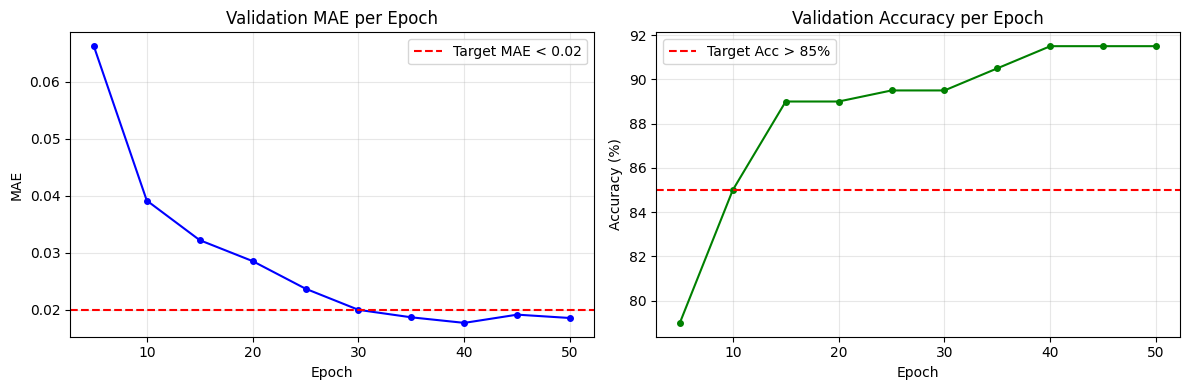

✅ Plot disimpan: training_history.png


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['epoch'], history['mae_val'], 'b-o', markersize=4)
ax1.axhline(y=0.02, color='r', linestyle='--', label='Target MAE < 0.02')
ax1.set_title('Validation MAE per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MAE')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['epoch'], [v*100 for v in history['acc_val']], 'g-o', markersize=4)
ax2.axhline(y=85, color='r', linestyle='--', label='Target Acc > 85%')
ax2.set_title('Validation Accuracy per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Plot disimpan: training_history.png")


## 7. Evaluasi Final (Test Set)

In [ ]:
#Load model terbaik
model_best = keras.models.load_model(
    "modalin_model.keras",
    custom_objects={'CreditScoringLayer': CreditScoringLayer}
)

#Prediksi pada test set
ps_test, pst_test = model_best(X_test_t, training=False)
mae_test  = float(np.mean(np.abs(ps_test.numpy().flatten() - y_test)))
acc_test  = float(np.mean(np.argmax(pst_test.numpy(), axis=1) == ys_test))
skor_range = df['total_skor'].max() - df['total_skor'].min()

#Cetak hasil
print(f"{'='*50}")
print(f"   HASIL EVALUASI FINAL — TEST SET")
print(f"{'='*50}")
print(f"  MAE (normalized)       : {mae_test:.4f}")
print(f"  MAE (skala skor 0–900) : {mae_test * skor_range:.1f} poin")
print(f"  MAE (skala 0–100)      : {mae_test * 100:.2f} poin")
print(f"  Accuracy Status        : {acc_test*100:.2f}%")
print(f"{'='*50}")
print(f"  MAE < 0.02 : {'✅ LOLOS' if mae_test < 0.02 else f'❌ GAGAL ({mae_test:.4f})'}")
print(f"  Acc > 85%  : {'✅ LOLOS' if acc_test > 0.85 else f'❌ GAGAL ({acc_test*100:.2f}%)'}")
print(f"{'='*50}")


   HASIL EVALUASI FINAL — TEST SET
  MAE (normalized)       : 0.0175
  MAE (skala skor 0–900) : 14.0 poin
  MAE (skala 0–100)      : 1.75 poin
  Accuracy Status        : 95.00%
  MAE < 0.02 : ✅ LOLOS
  Acc > 85%  : ✅ LOLOS


## 8. SHAP — Explainable AI

SHAP (*SHapley Additive exPlanations*) menjelaskan **kontribusi setiap fitur** terhadap prediksi model. Ini memenuhi kriteria transparansi XAI pada proyek ModalIn.

Menghitung SHAP values (mungkin butuh beberapa menit)...


  0%|          | 0/50 [00:00<?, ?it/s]

✅ SHAP values selesai dihitung.


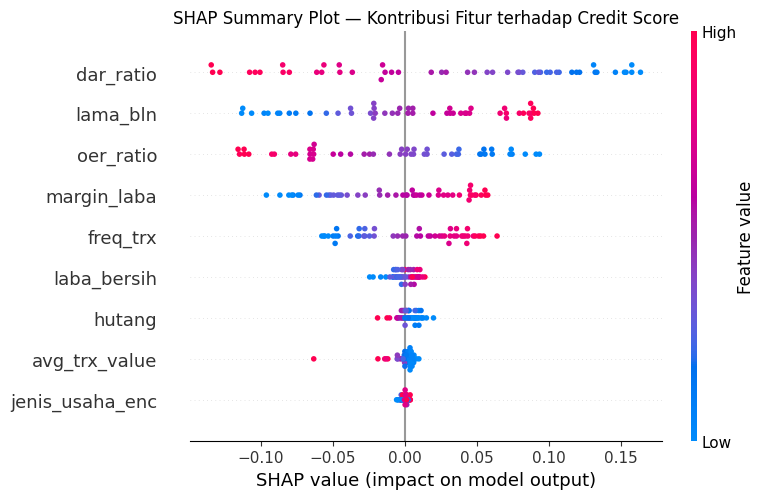

✅ SHAP plot disimpan: shap_summary.png


In [ ]:
#Buat wrapper untuk SHAP (model multi-output → ambil output skor)
def model_predict_skor(X):
    X_t = tf.cast(X, tf.float32)
    skor, _ = model_best(X_t, training=False)
    return skor.numpy().flatten()

#Gunakan subset train sebagai background
background = X_train[:100]
explainer  = shap.KernelExplainer(model_predict_skor, background)

#Hitung SHAP values pada 50 sampel test
print("Menghitung SHAP values (mungkin butuh beberapa menit)...")
shap_values = explainer.shap_values(X_test[:50], nsamples=100)
print("✅ SHAP values selesai dihitung.")

#Plot Summary
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test[:50],
    feature_names=FEATURES_FINAL,
    show=False
)
plt.title("SHAP Summary Plot — Kontribusi Fitur terhadap Credit Score")
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ SHAP plot disimpan: shap_summary.png")


## 9. Inference — Contoh Prediksi

Fungsi `predict_credit_score()` ini nantinya akan dipanggil oleh **FastAPI** sebagai microservice inference.

In [ ]:
def predict_credit_score(input_data: dict) -> dict:
    """
    Menerima data mentah dari form frontend,
    menghitung fitur, lalu prediksi kredit UMKM.
    """
    STATUS_MAP = {0: 'Tidak Layak', 1: 'Review', 2: 'Layak'}

    #Hitung fitur dari data mentah
    omzet       = input_data['omzet']
    pengeluaran = input_data['pengeluaran']
    aset        = input_data['aset']
    hutang      = input_data['hutang']
    freq_trx    = input_data['freq_trx']
    laba_bersih = omzet - pengeluaran

    fitur = {
        'margin_laba'    : (laba_bersih / omzet) * 100,
        'dar_ratio'      : hutang / (aset + 1),
        'oer_ratio'      : pengeluaran / (omzet + 1),
        'avg_trx_value'  : omzet / (freq_trx + 1),
        'laba_bersih'    : laba_bersih,
        'lama_bln'       : input_data['lama_bln'],
        'freq_trx'       : freq_trx,
        'hutang'         : hutang,
        'jenis_usaha_enc': int(le.transform([input_data['jenis_usaha']])[0])
    }

    #Scale & prediksi
    row    = np.array([[fitur[f] for f in FEATURES_FINAL]], dtype=np.float32)
    row_sc = scaler.transform(row)
    row_t  = tf.cast(row_sc, tf.float32)

    skor_norm, status_prob = model_best(row_t, training=False)
    skor_norm_val = float(skor_norm.numpy()[0][0])
    skor_asli_val = float(skor_scaler.inverse_transform([[skor_norm_val]])[0][0])
    status_idx    = int(np.argmax(status_prob.numpy()[0]))

    return {
        'skor_kredit' : round(skor_asli_val, 1),
        'status'      : STATUS_MAP[status_idx],
        'probabilitas': {
            STATUS_MAP[i]: round(float(p), 4)
            for i, p in enumerate(status_prob.numpy()[0])
        }
    }


#Contoh pakai data mentah (seperti dari form frontend)
contoh_umkm = {
    'omzet'       : 5_000_000,
    'pengeluaran' : 3_750_000,
    'aset'        : 25_000_000,
    'hutang'      : 5_000_000,
    'freq_trx'    : 150,
    'lama_bln'    : 36.0,
    'jenis_usaha' : 'Bisnis Kuliner'   # string asli, bukan angka
}

hasil = predict_credit_score(contoh_umkm)
print("=" * 40)
print("  Hasil Prediksi Kredit UMKM")
print("=" * 40)
print(f"  Skor Kredit  : {hasil['skor_kredit']} / 900")
print(f"  Status       : {hasil['status']}")
print(f"  Probabilitas : {hasil['probabilitas']}")
print("=" * 40)

  Hasil Prediksi Kredit UMKM
  Skor Kredit  : 566.4 / 900
  Status       : Review
  Probabilitas : {'Tidak Layak': 0.088, 'Review': 0.8479, 'Layak': 0.0642}


In [ ]:
#10. Zip & Download Semua Hasil Training Model
import zipfile
import os
from google.colab import files

#File yang mau dizip
ARTIFACTS = [
    "modalin_model.keras",
    "scaler.pkl",
    "skor_scaler.pkl",
    "label_encoder.pkl",
    "features.pkl",
    "shap_summary.png",
    "training_history.png",
]

ZIP_NAME = "modalin_artifacts.zip"

#Buat zip
with zipfile.ZipFile(ZIP_NAME, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in ARTIFACTS:
        if os.path.exists(fname):
            zf.write(fname)
            print(f"  ✅ {fname}")
        else:
            print(f"  ⚠️  {fname} — tidak ditemukan, dilewati")

print(f"\n📦 ZIP berhasil dibuat: {ZIP_NAME}")
print(f"📁 Total file: {len(zf.namelist())}")

#Download otomatis
files.download(ZIP_NAME)
print("⬇️  Download dimulai...")

  ✅ modalin_model.keras
  ✅ scaler.pkl
  ✅ skor_scaler.pkl
  ✅ label_encoder.pkl
  ✅ features.pkl
  ✅ shap_summary.png
  ✅ training_history.png

📦 ZIP berhasil dibuat: modalin_artifacts.zip
📁 Total file: 7


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download dimulai...
